# **Stage 3 - Analysis**
# **Data visualization and interpretation.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load processed data from Stage 2
df = pd.read_csv("/content/drive/MyDrive/Student_Performance_Analysis/Data_Clean/std_Performance_processed.csv")

# **V1 — Gender Boxplots (Math vs Reading)**

# **Question: Are there gender differences in math vs reading scores?**

/tmp/ipython-input-2140/3456912849.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipython-input-2140/3456912849.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


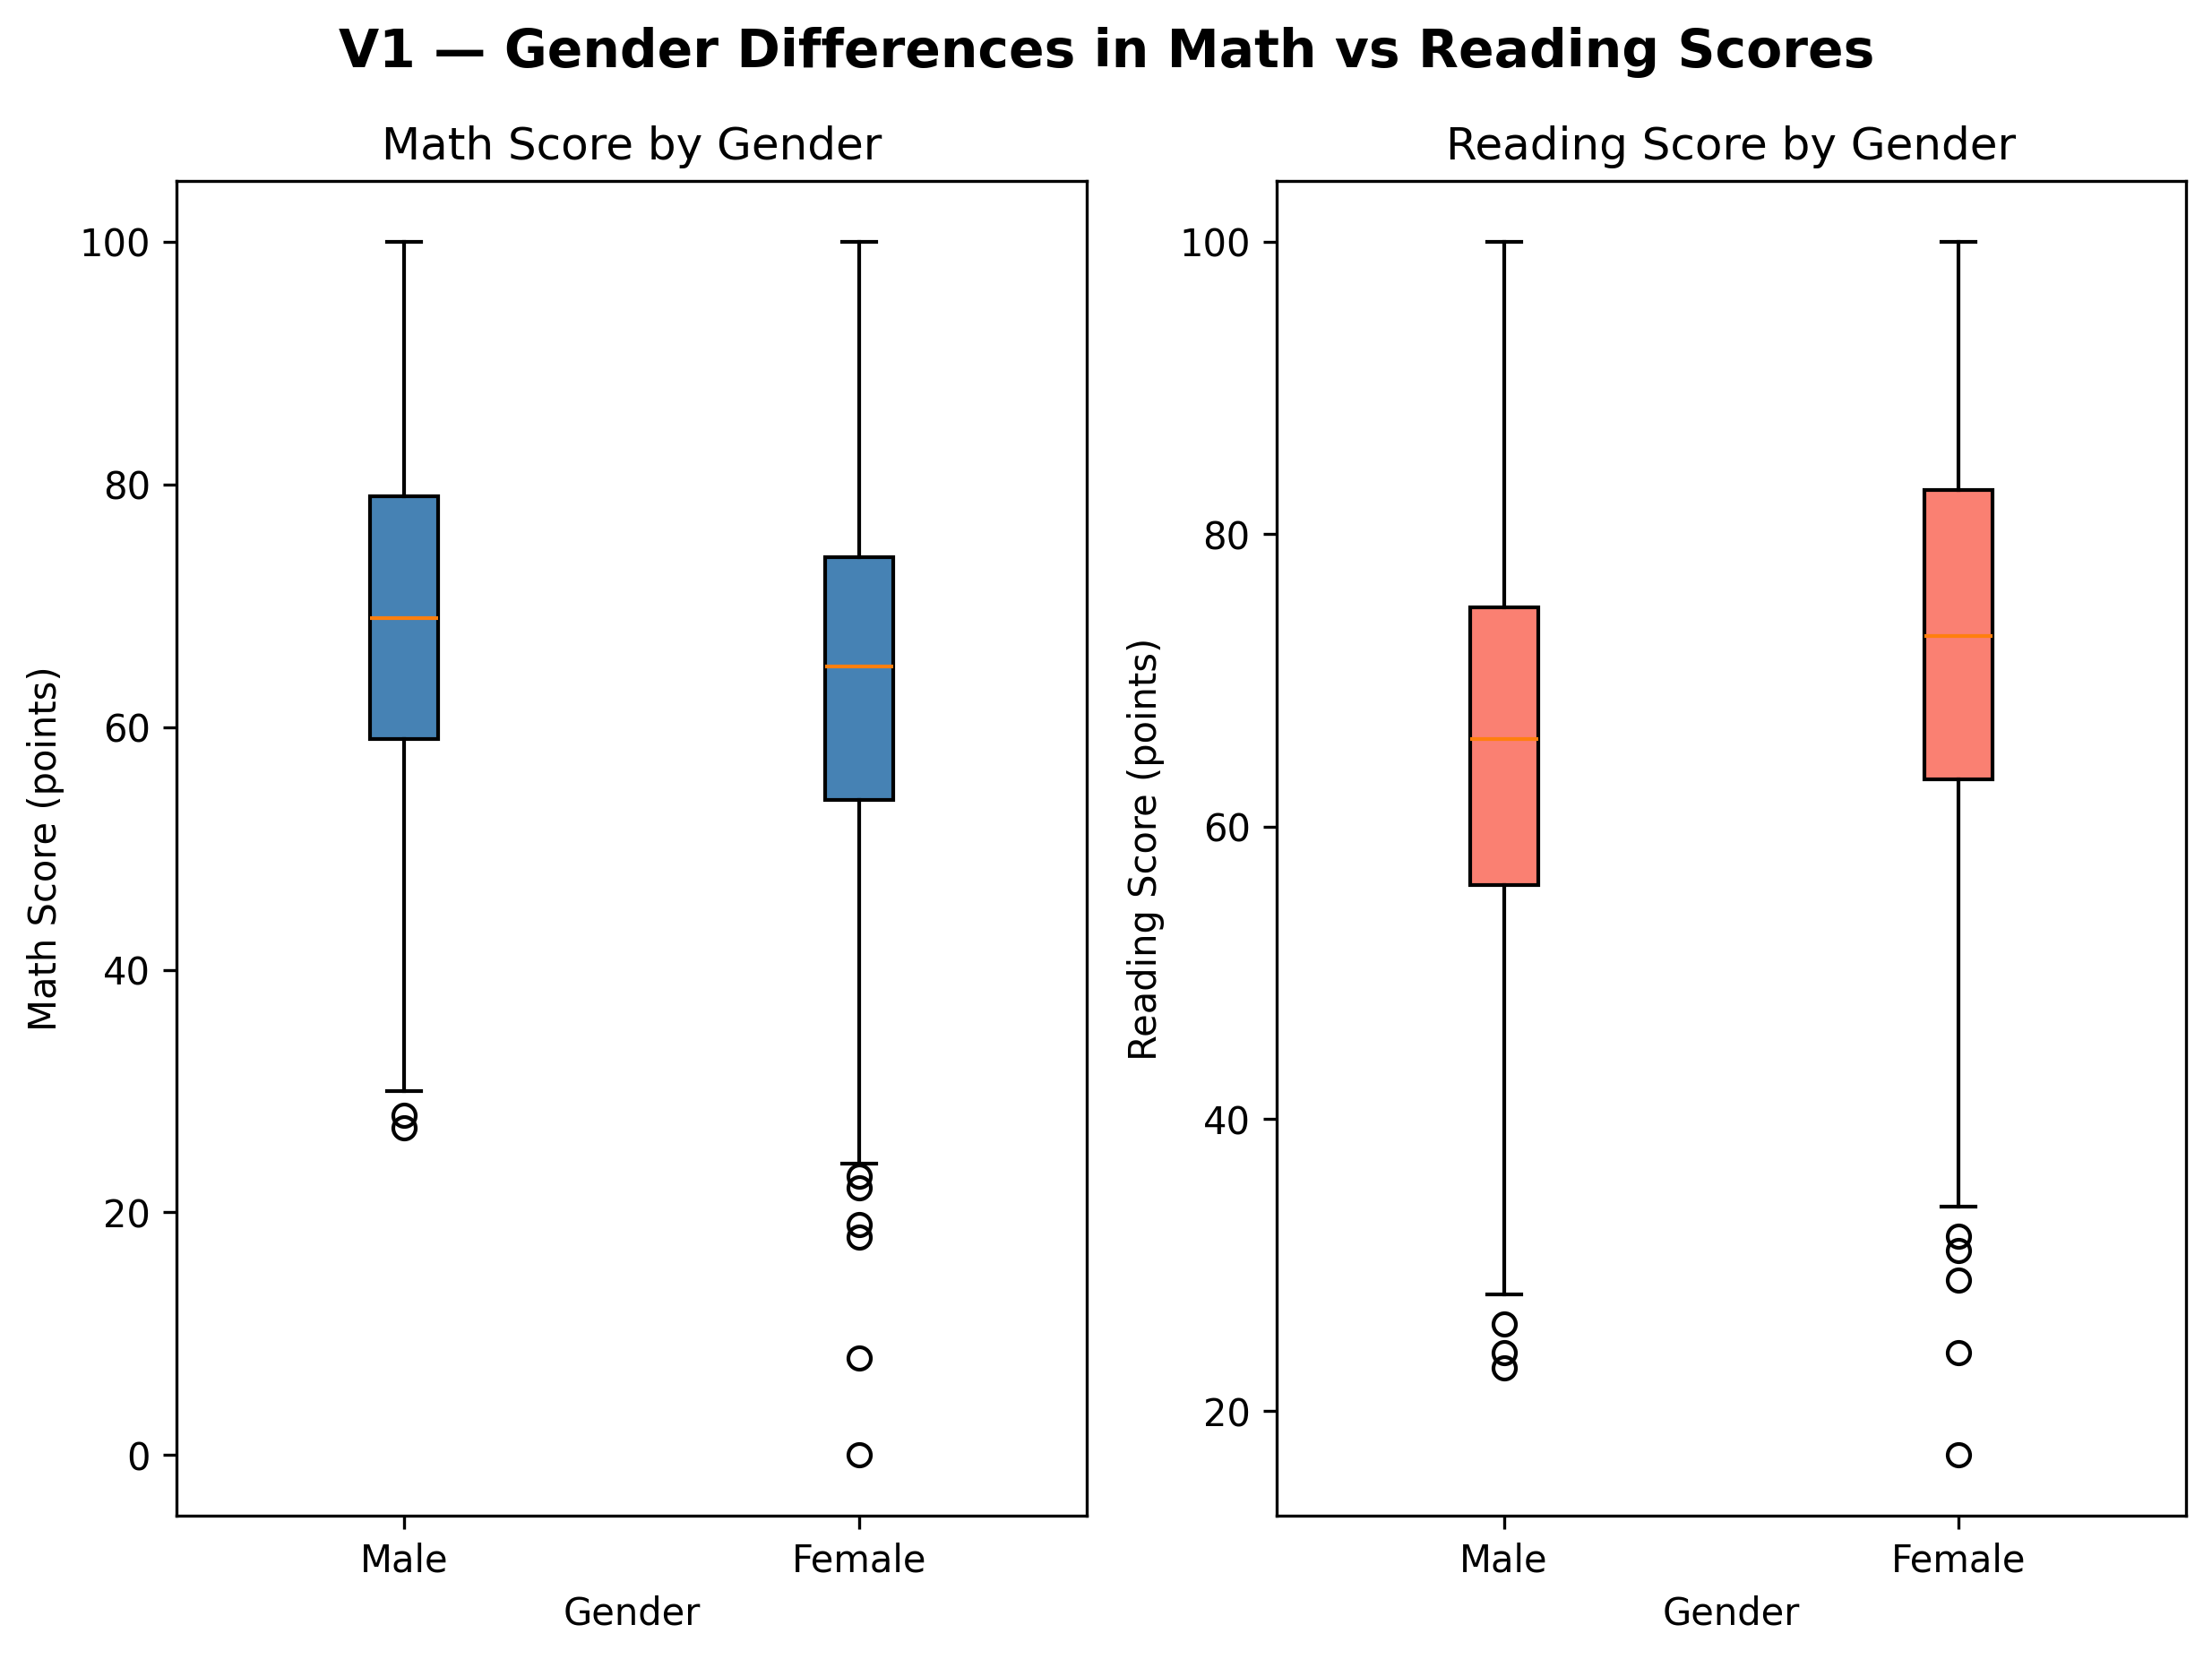

V1 saved!


In [4]:
# V1 - Do males and females perform differently in math vs reading?
# Using boxplots to see the full distribution across both subjects

fig, axes = plt.subplots(1, 2, figsize=(800/96, 600/96), dpi=300)

# Split dataset by gender
male_data   = df[df['gender'] == 'male']
female_data = df[df['gender'] == 'female']

# Math scores by gender
axes[0].boxplot(
    [male_data['math score'], female_data['math score']],
    labels=['Male', 'Female'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue')
)
axes[0].set_title('Math Score by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Math Score (points)')

# Reading scores by gender
axes[1].boxplot(
    [male_data['reading score'], female_data['reading score']],
    labels=['Male', 'Female'],
    patch_artist=True,
    boxprops=dict(facecolor='salmon')
)
axes[1].set_title('Reading Score by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Reading Score (points)')

fig.suptitle('V1 — Gender Differences in Math vs Reading Scores',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Student_Performance_Analysis/Reports/Figures/V1_gender_boxplots.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("V1 saved!")

In [5]:
# Save V1 interpretation to Reports/findings.md
report_path = "/content/drive/MyDrive/Student_Performance_Analysis/Reports/findings.md"

with open(report_path, 'w') as f:
    f.write("# Student Performance Analysis - Findings Report\n\n")
    f.write("## V1 — Gender Boxplots (Math vs Reading)\n\n")
    f.write("Looking at the boxplots, male students clearly do better in math compared to female students. ")
    f.write("The median math score for males is higher, which shows this difference quite well. ")
    f.write("When it comes to reading though, the situation flips female students have a noticeably higher median reading score than males. ")
    f.write("The spread of scores is pretty similar for both genders in math, so the gap is mainly in the middle. ")
    f.write("In reading, females show a bit more variation in their scores. ")
    f.write("There are a few outliers at the bottom in both subjects, which are students who scored much lower than everyone else. ")
    f.write("Overall, it seems like males lean more toward math while females are stronger in reading.\n\n")

print("V1 interpretation saved!")

V1 interpretation saved!


# **V2 — Test Prep Impact on Math Score**
# **Question: Do students who completed test prep score higher in math?**

/tmp/ipython-input-2140/3575043958.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  test_prep_plot = ax.boxplot(test_prep_groups, labels=['Completed', 'None'], patch_artist=True)


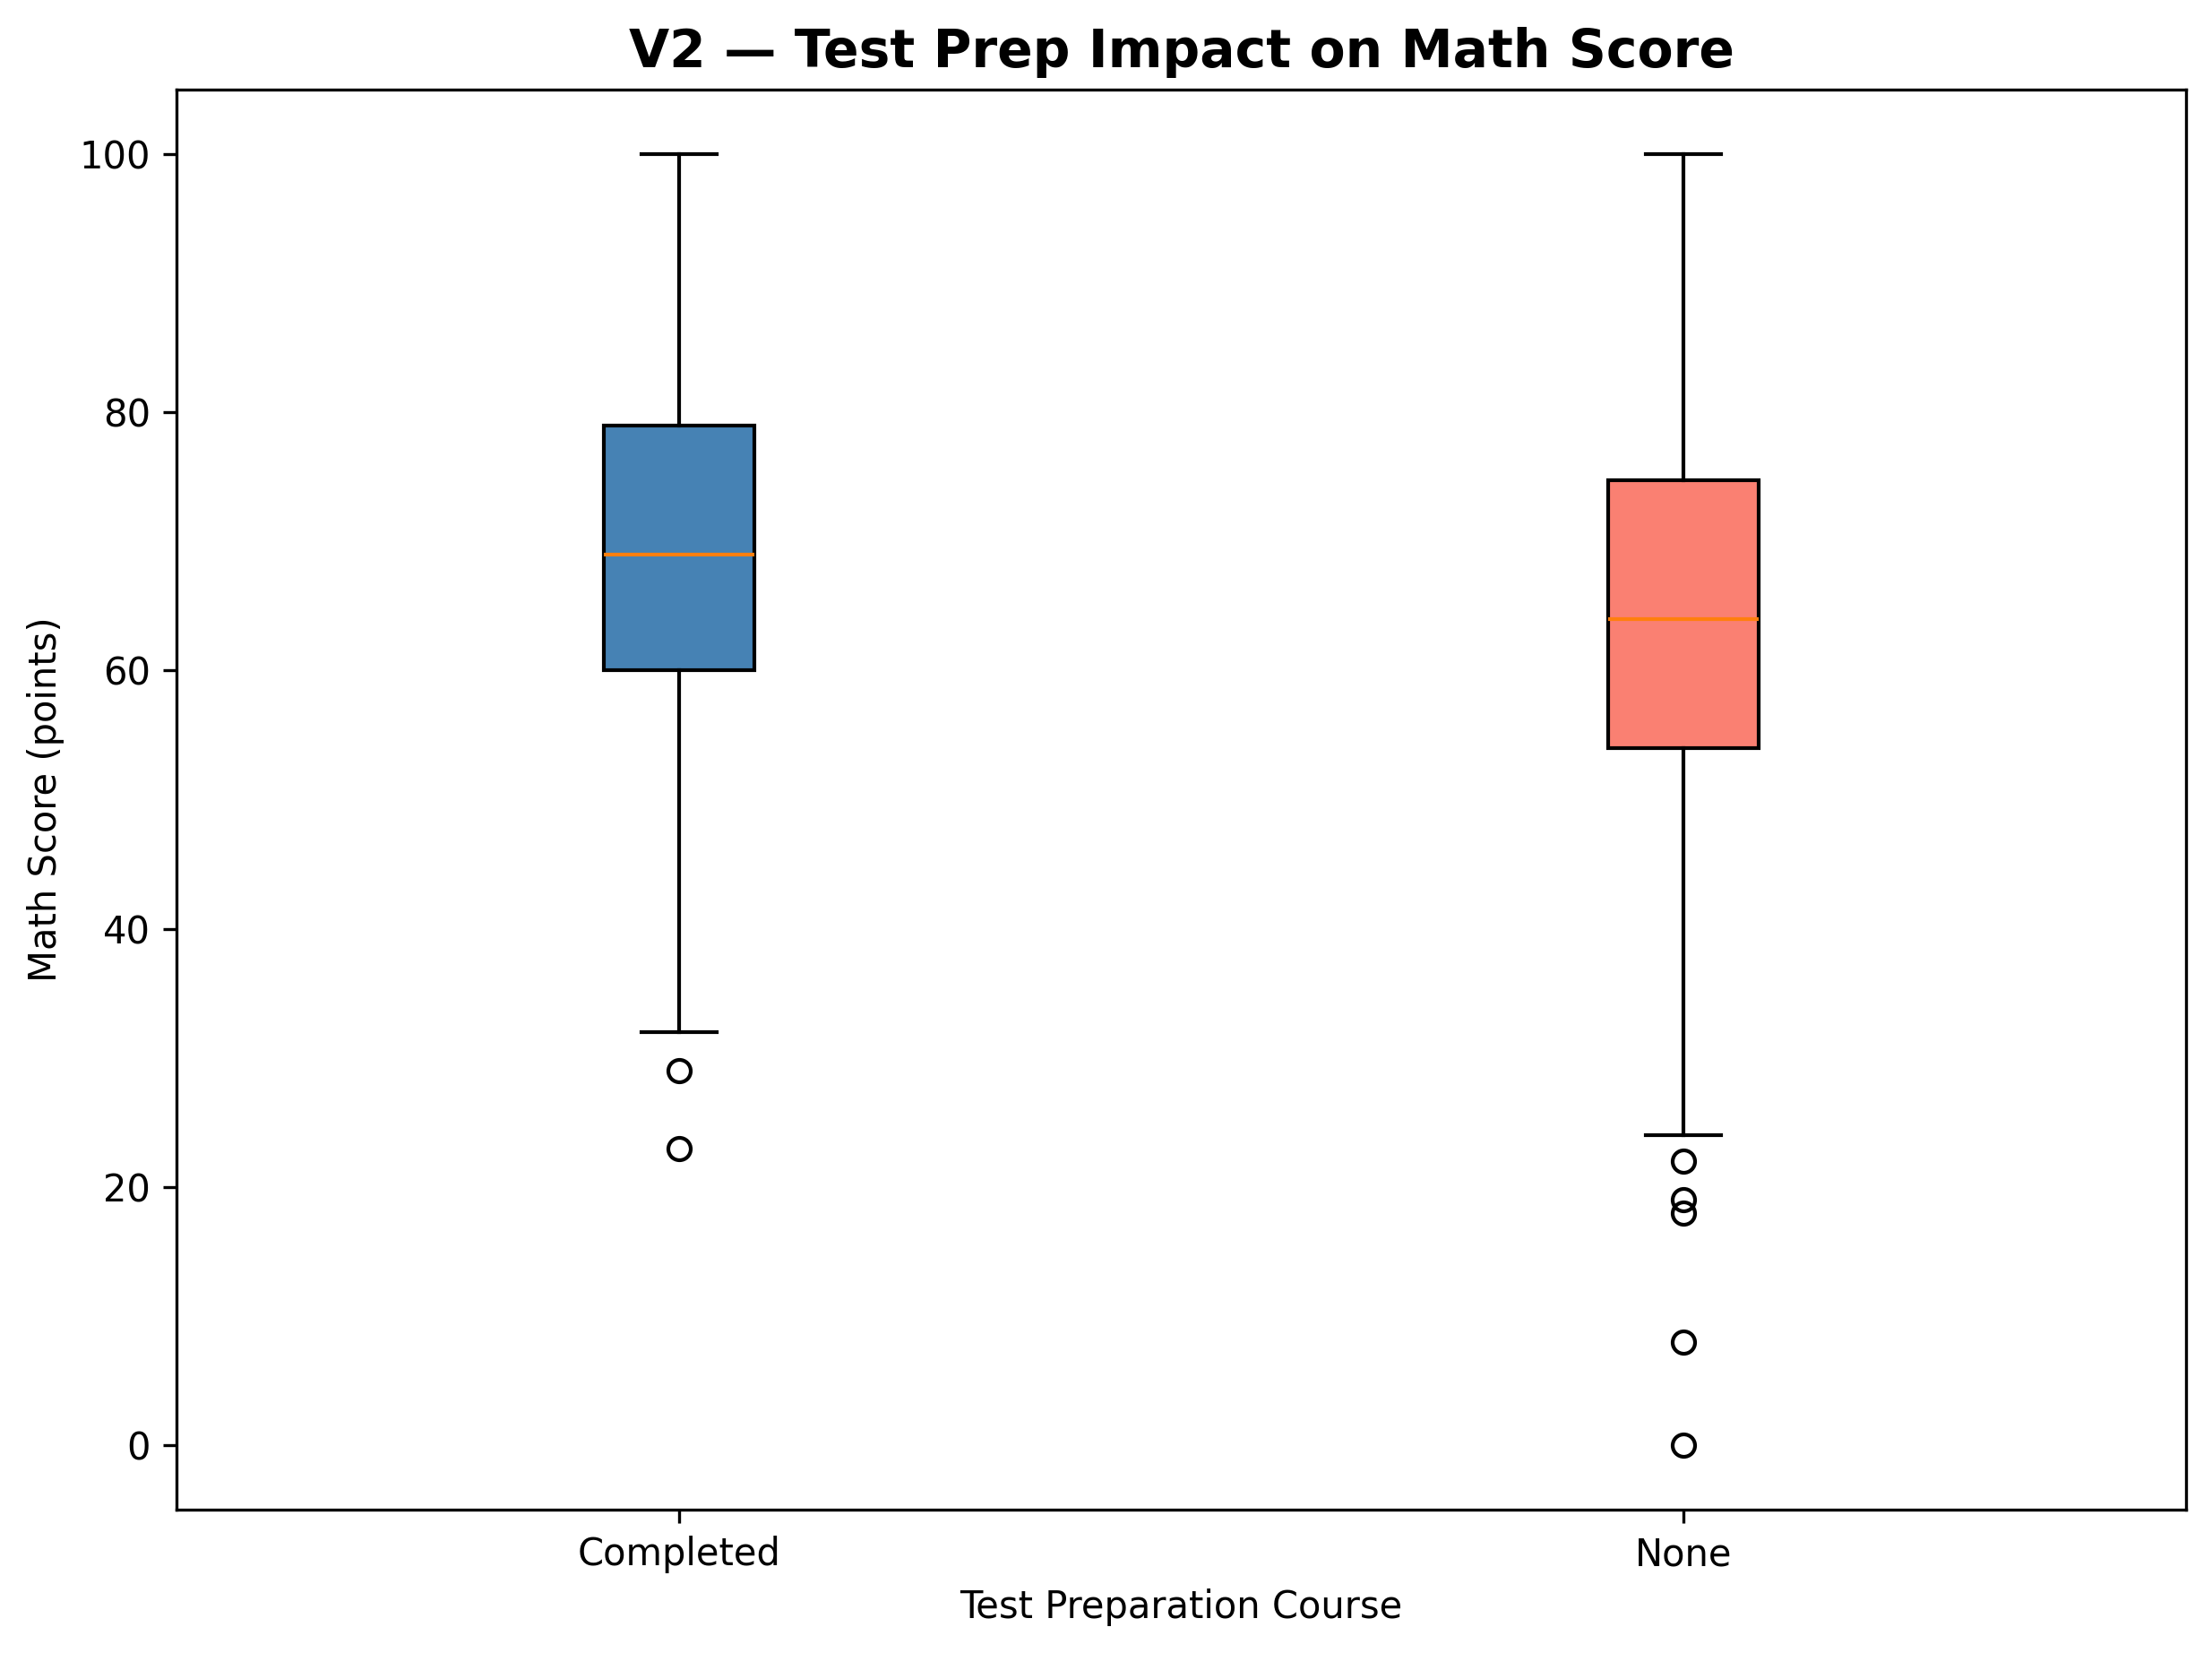

V2 saved!


In [8]:
# V2 - Do students who completed test prep score higher in math?
# Boxplot shows the full distribution of math scores for each test prep group

fig, ax = plt.subplots(figsize=(800/96, 600/96), dpi=300)

# Group math scores based on whether student completed test prep or not
test_prep_groups = [
    df[df['test preparation course'] == 'completed']['math score'],
    df[df['test preparation course'] == 'none']['math score']
]

# Plot and color each group differently for clarity
test_prep_plot = ax.boxplot(test_prep_groups, labels=['Completed', 'None'], patch_artist=True)

test_prep_plot['boxes'][0].set_facecolor('steelblue')
test_prep_plot['boxes'][1].set_facecolor('salmon')

ax.set_title('V2 — Test Prep Impact on Math Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Test Preparation Course')
ax.set_ylabel('Math Score (points)')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Student_Performance_Analysis/Reports/Figures/V2_testprep_math.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("V2 saved!")

In [9]:
# Save V2 interpretation to Reports/findings.md
with open(report_path, 'a') as f:
    f.write("## V2 — Test Prep Impact on Math Score\n\n")
    f.write("Students who completed the test preparation course clearly scored higher in math compared to those who did not. ")
    f.write("The median math score for the completed group is noticeably higher, which shows that test prep does make a difference. ")
    f.write("The completed group also has less variation in scores, meaning most students who did prep performed consistently well. ")
    f.write("On the other hand, students with no test prep show more spread in their scores and a lower median. ")
    f.write("Both groups have some outliers at the lower end, but there are more in the none group. ")
    f.write("Overall, it looks like doing test prep is worth it when it comes to math performance.\n\n")

print("V2 interpretation saved!")

V2 interpretation saved!


# **V3 — Lunch Type and Average Performance**
# **Question: Does lunch type (standard vs free/reduced) relate to outcomes?**

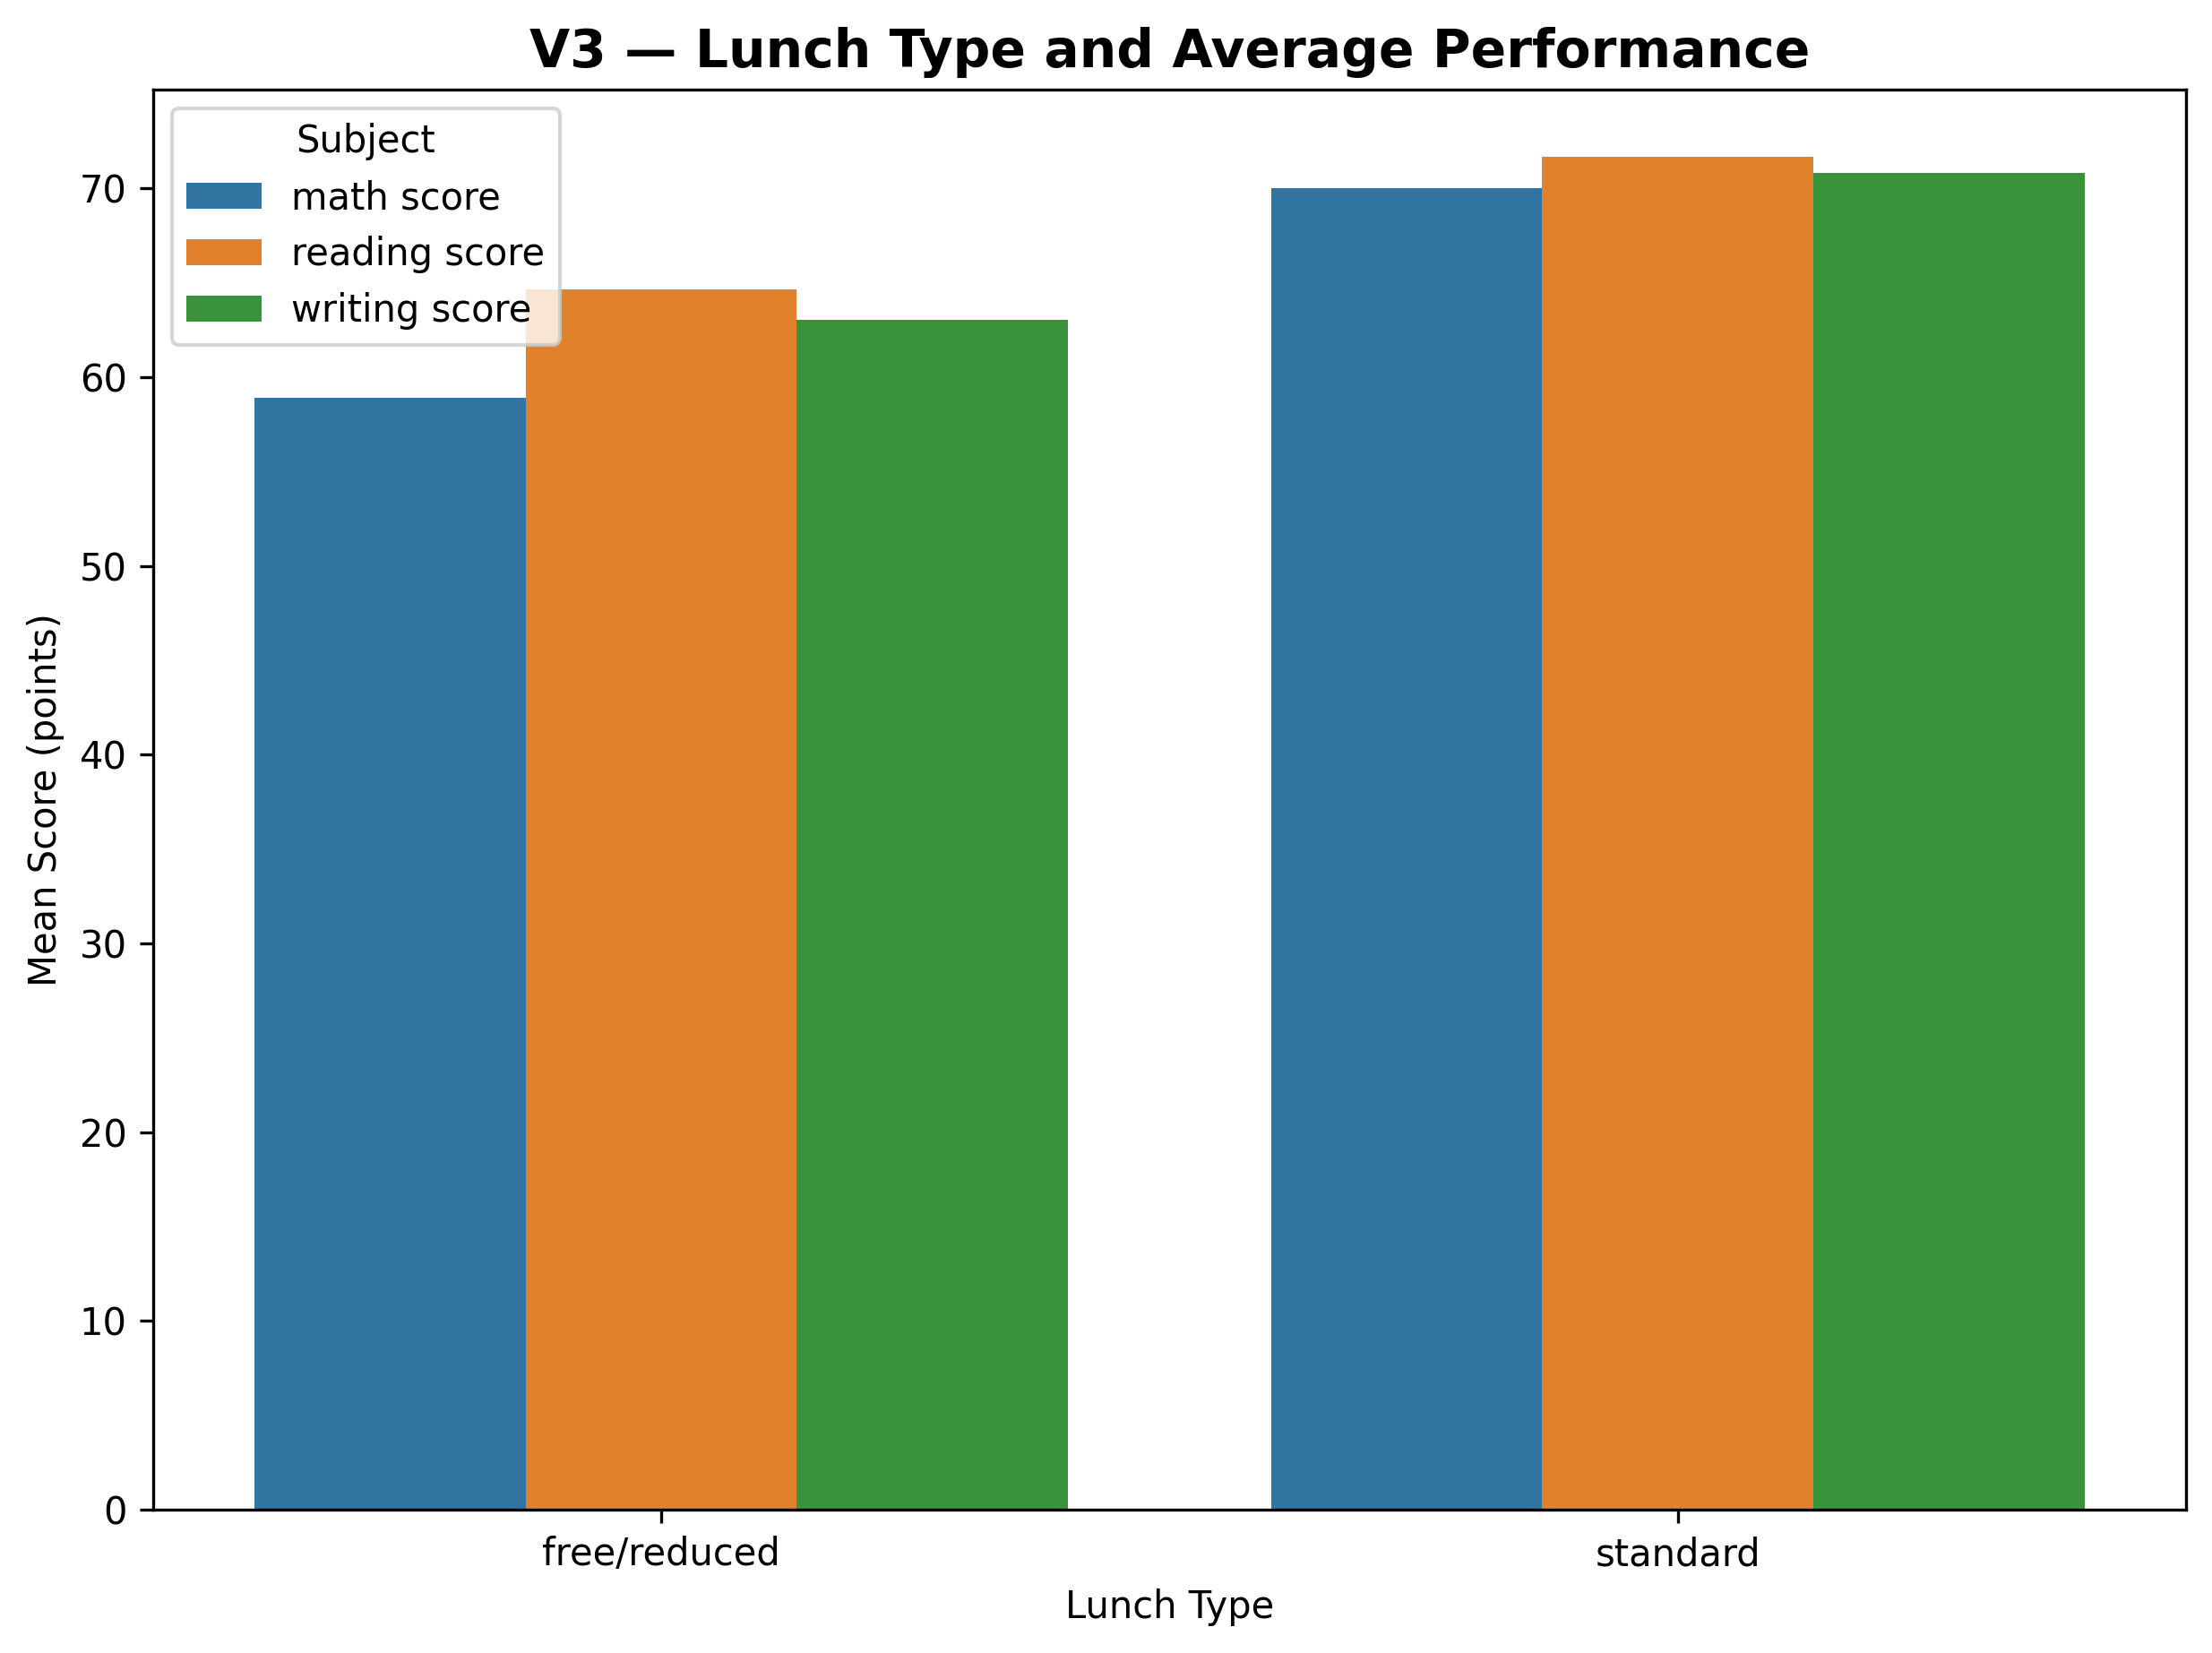

V3 saved!


In [10]:
import seaborn as sns

# V3 - Does lunch type affect overall student performance?
# Grouped bar chart showing mean score for each subject by lunch type

fig, ax = plt.subplots(figsize=(800/96, 600/96), dpi=300)

# Calculate mean scores grouped by lunch type
lunch_avg = df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean().reset_index()

# Reshape for seaborn grouped bar chart
lunch_scores = lunch_avg.melt(id_vars='lunch', var_name='Subject', value_name='Mean Score')

# Grouped bar chart
sns.barplot(data=lunch_scores, x='lunch', y='Mean Score', hue='Subject', ax=ax)

ax.set_title('V3 — Lunch Type and Average Performance', fontsize=14, fontweight='bold')
ax.set_xlabel('Lunch Type')
ax.set_ylabel('Mean Score (points)')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Student_Performance_Analysis/Reports/Figures/V3_lunch_performance.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("V3 saved!")

In [11]:
# Save V3 interpretation to Reports/findings.md
with open(report_path, 'a') as f:
    f.write("## V3 — Lunch Type and Average Performance\n\n")
    f.write("Students who have a standard lunch perform better in all three subjects compared to students on free or reduced lunch. ")
    f.write("The difference is visible in math, reading, and writing — standard lunch students score around 10 points higher on average. ")
    f.write("This pattern is consistent across all subjects, which means lunch type seems to have a broad effect on overall performance. ")
    f.write("It could be that students with standard lunch have better nutrition or come from a more stable background. ")
    f.write("Either way, the chart makes it pretty clear that lunch type is linked to how well students do in school.\n\n")

print("V3 interpretation saved!")

V3 interpretation saved!


# **V4 — Subject Correlations**
# **Question: How strongly do the three subjects move together?**

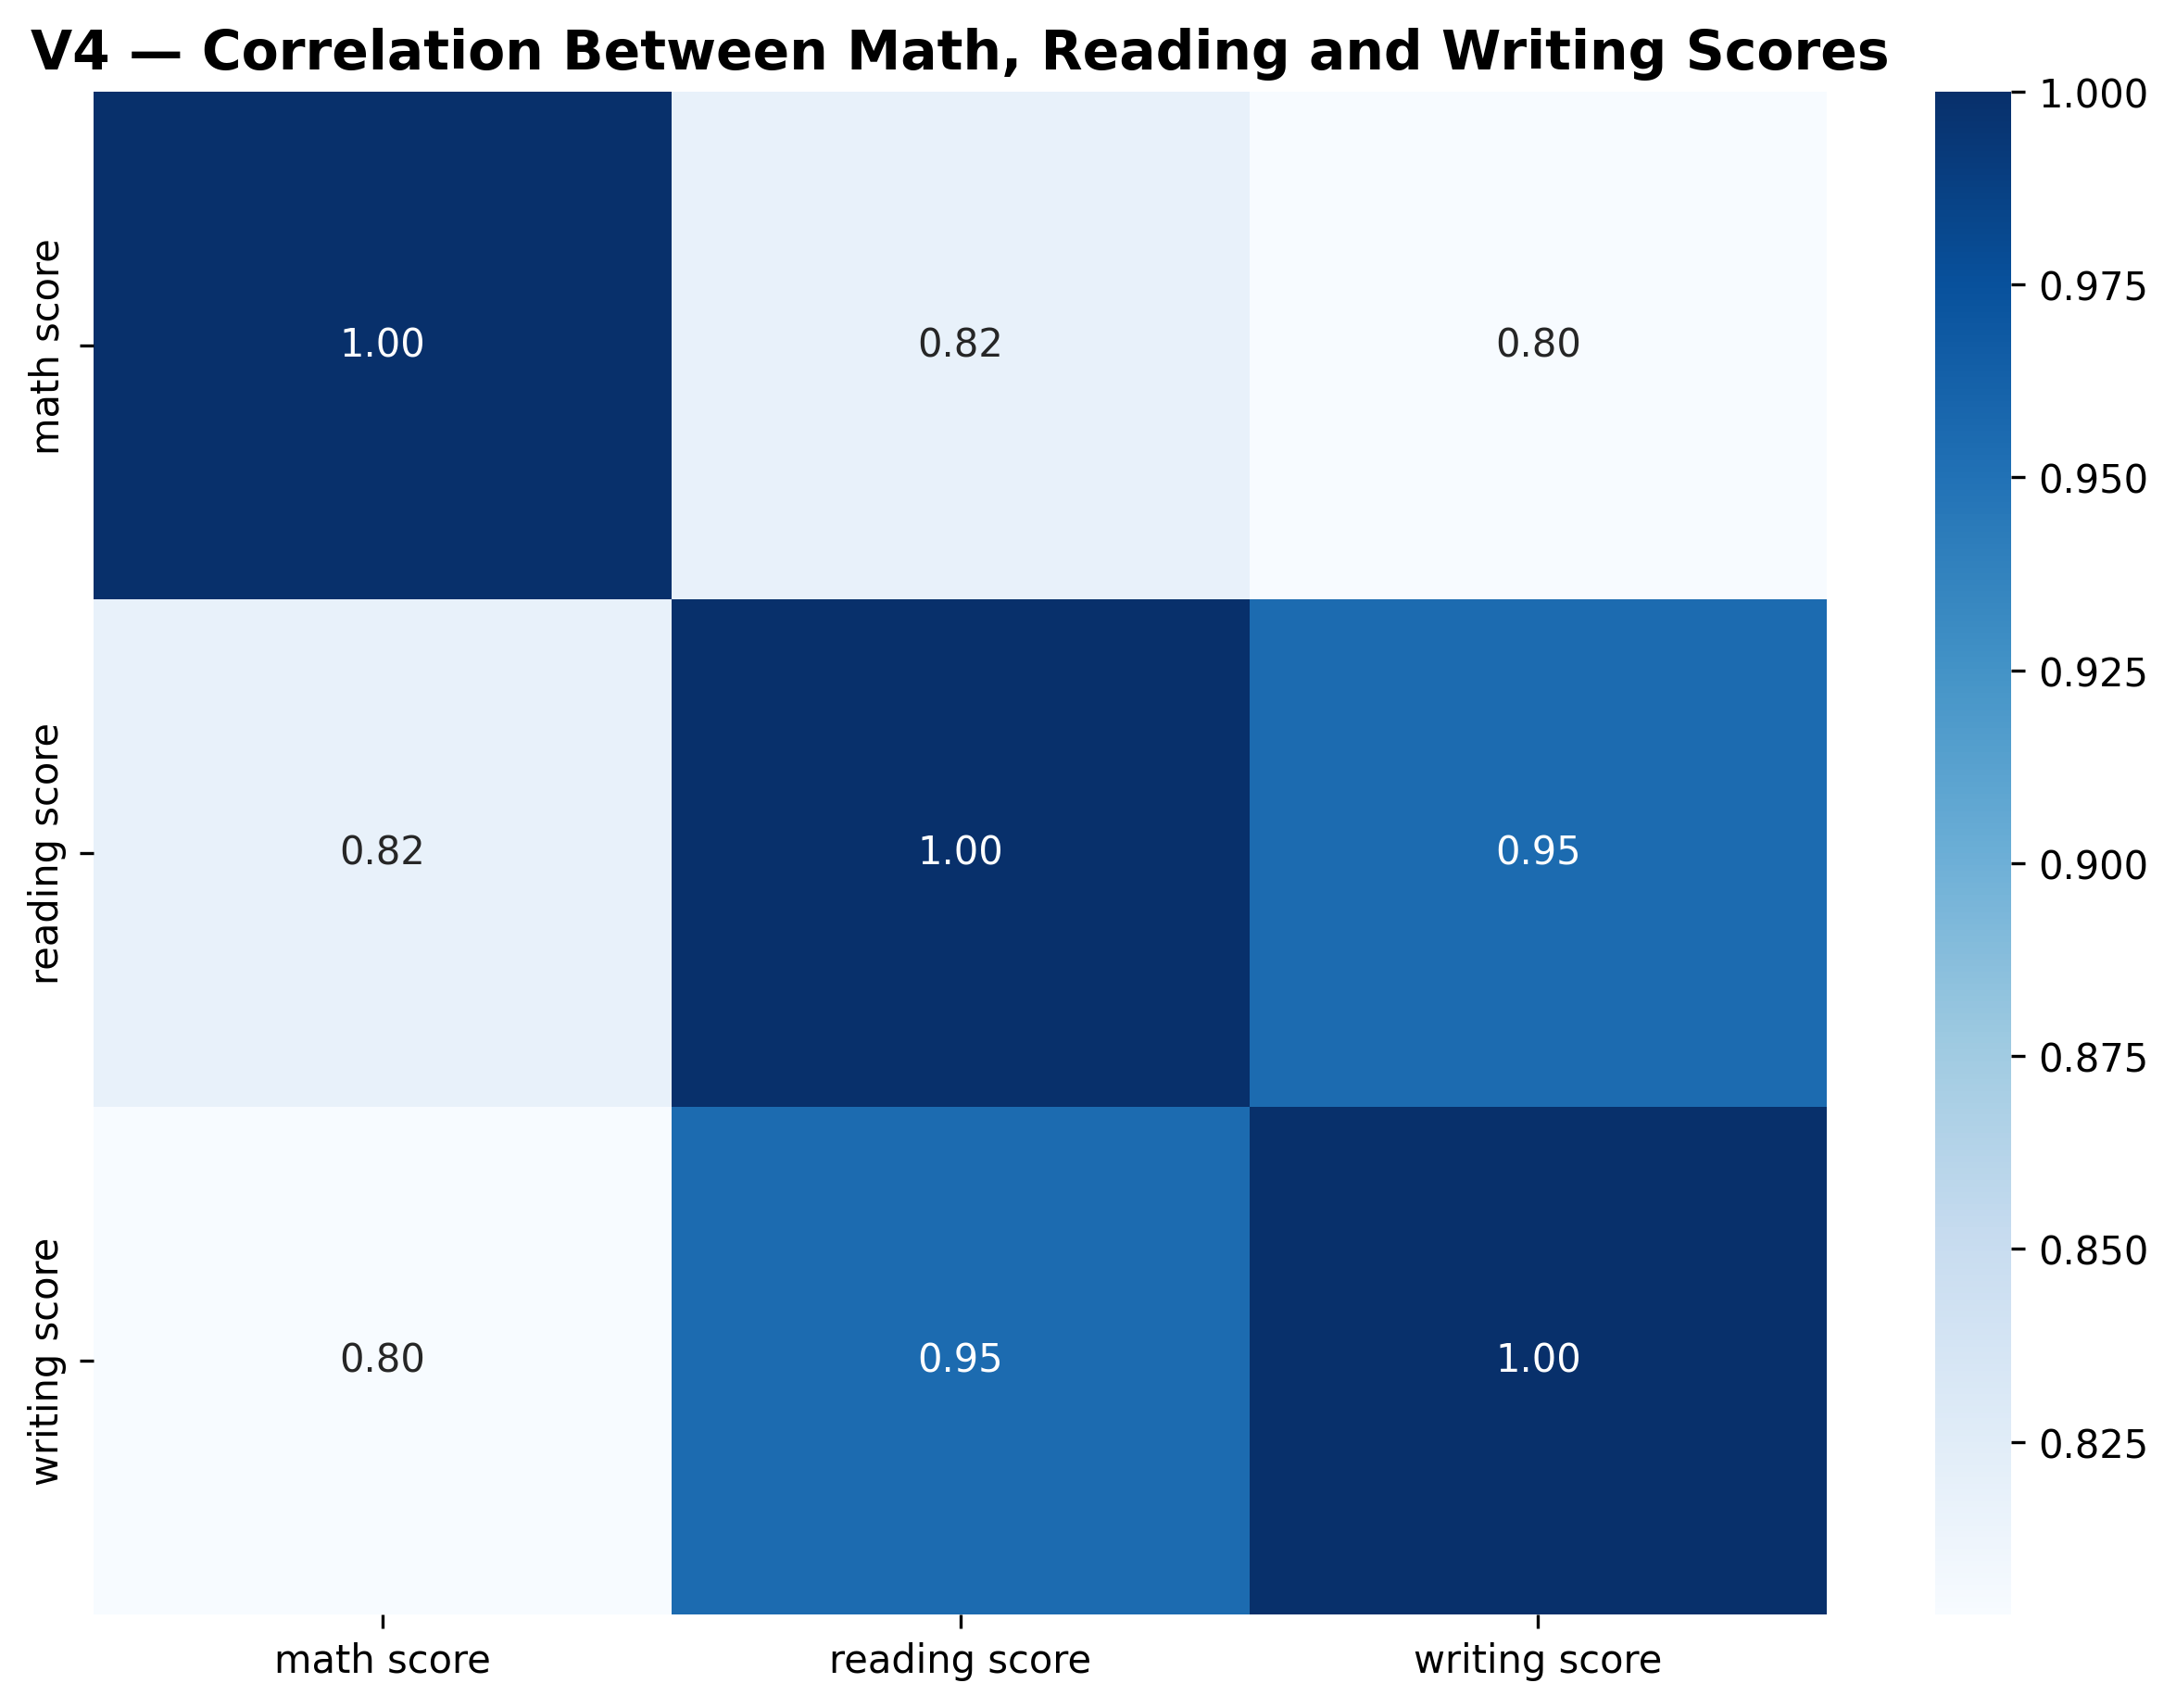

V4 saved!


In [13]:
# V4 - How strongly are math, reading and writing scores related?

fig, ax = plt.subplots(figsize=(800/96, 600/96), dpi=300)

# Select the three subject scores
three_subjects = df[['math score', 'reading score', 'writing score']]

# Compute correlation matrix
subject_correlation = three_subjects.corr()

# Heatmap with values shown inside each cell
sns.heatmap(subject_correlation, annot=True, fmt='.2f', cmap='Blues', ax=ax)

ax.set_title('V4 — Correlation Between Math, Reading and Writing Scores',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Student_Performance_Analysis/Reports/Figures/V4_subject_correlations.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("V4 saved!")

In [14]:
# Save V4 interpretation to Reports/findings.md
with open(report_path, 'a') as f:
    f.write("## V4 — Subject Correlations\n\n")
    f.write("Looking at the heatmap, all three subjects are pretty strongly correlated with each other. ")
    f.write("Reading and writing have the highest correlation of 0.95, which makes sense since both involve language skills. ")
    f.write("Math and reading are also strongly related at 0.82, and math and writing at 0.80. ")
    f.write("This means if a student is doing well in one subject, they are likely doing well in the others too. ")
    f.write("Overall, the three subjects move together quite closely, suggesting that general academic ability plays a big role across all subjects.\n\n")

print("V4 interpretation saved!")

V4 interpretation saved!


# **V5 — Math vs Reading with Trend Lines by Test Prep**
# **Question: How strongly are math and reading scores associated, and does test prep affect this relationship?**

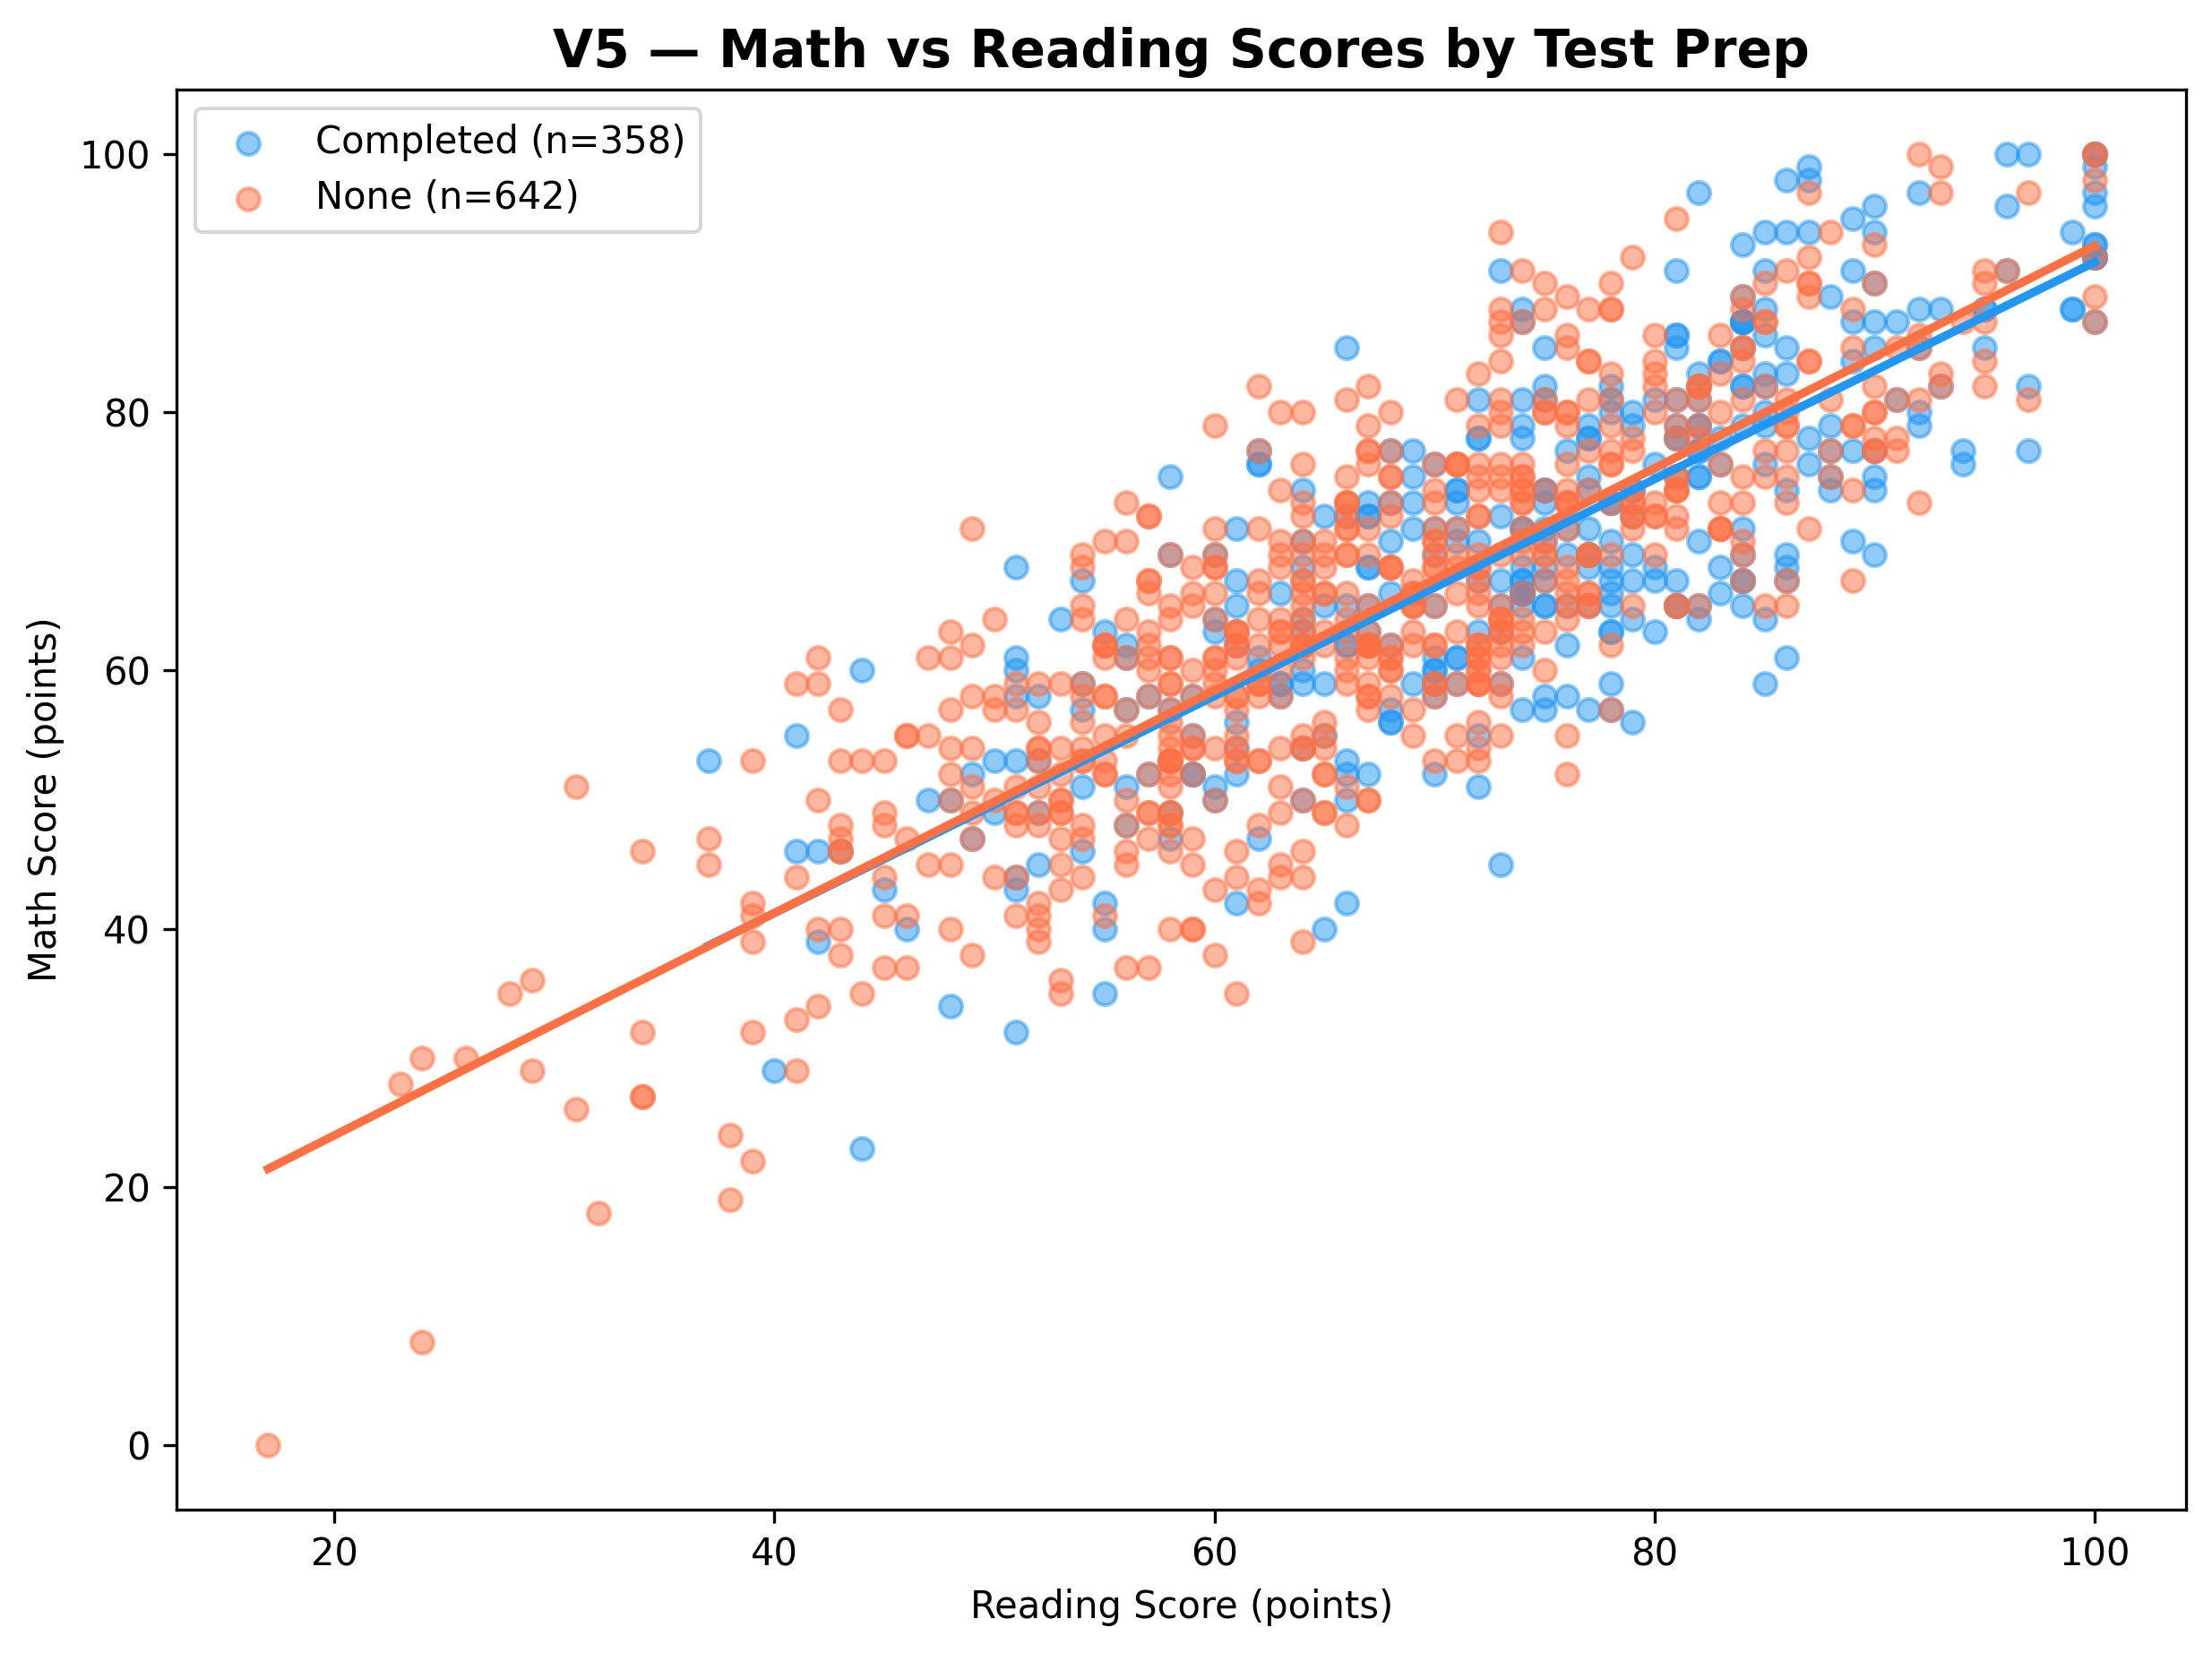

V5 saved!


In [15]:
# V5 - Does test prep change how math and reading scores relate to each other?

fig, ax = plt.subplots(figsize=(800/96, 600/96), dpi=300)

# completed students - scatter + best fit line
completed_count = len(df[df['test preparation course'] == 'completed'])
sns.regplot(data=df[df['test preparation course'] == 'completed'],
            x='reading score', y='math score', ci=None,
            color='#2196F3', scatter_kws={'alpha': 0.5},
            label=f'Completed (n={completed_count})', ax=ax)

# no prep students - scatter + best fit line
no_prep_count = len(df[df['test preparation course'] == 'none'])
sns.regplot(data=df[df['test preparation course'] == 'none'],
            x='reading score', y='math score', ci=None,
            color='#FF7043', scatter_kws={'alpha': 0.5},
            label=f'None (n={no_prep_count})', ax=ax)

ax.set_title('V5 — Math vs Reading Scores by Test Prep', fontsize=14, fontweight='bold')
ax.set_xlabel('Reading Score (points)')
ax.set_ylabel('Math Score (points)')
ax.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Student_Performance_Analysis/Reports/Figures/V5_math_reading_testprep.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("V5 saved!")

In [16]:
# Save V5 interpretation to Reports/findings.md
with open(report_path, 'a') as f:
    f.write("## V5 — Math vs Reading with Trend Lines by Test Prep\n\n")
    f.write("Looking at the scatter plot, there is a clear positive trend — students who score higher in reading also tend to score higher in math. ")
    f.write("This is true for both groups. ")
    f.write("Students who completed test prep are mostly scoring higher in math compared to those who did not, even at the same reading level. ")
    f.write("The two trend lines have a similar slope, meaning the relationship between reading and math does not change much with test prep. ")
    f.write("But the completed group line is slightly higher, showing that test prep does give a small advantage in math. ")
    f.write("Overall, reading score is a good indicator of how a student will do in math.\n\n")

print("V5 interpretation saved!")

V5 interpretation saved!
